In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import KMeans



In [18]:
catlog = pd.read_csv("Audible_Catlog.csv")
features = pd.read_csv("Audible_Catlog_Advanced_Features.csv")

print("catlog shape:", catlog.shape)
print("features shape:", features.shape)

catlog.head()
features.head()

print(catlog.columns)
print(features.columns)

catlog shape: (6368, 5)
features shape: (4464, 8)
Index(['Book Name', 'Author', 'Rating', 'Number of Reviews', 'Price'], dtype='object')
Index(['Book Name', 'Author', 'Rating', 'Number of Reviews', 'Price',
       'Description', 'Listening Time', 'Ranks and Genre'],
      dtype='object')


In [19]:
df = pd.merge(catlog, features, on="Book Name", how="inner")

print("Duplicate rows:", df.duplicated().sum())

df.drop_duplicates(inplace=True)

print("After removal:", df.shape)

df['Number of Reviews_x'] = df['Number of Reviews_x'].fillna('')
df['Number of Reviews_y'] = df['Number of Reviews_y'].fillna('')
df['Price_x'] = df['Price_x'].fillna('')
df['Description'] = df['Description'].fillna('')

print(df.isnull().sum())

Duplicate rows: 646
After removal: (3624, 12)
Book Name              0
Author_x               0
Rating_x               0
Number of Reviews_x    0
Price_x                0
Author_y               0
Rating_y               0
Number of Reviews_y    0
Price_y                0
Description            0
Listening Time         0
Ranks and Genre        0
dtype: int64


In [20]:
df.columns = df.columns.str.strip().str.lower()

df.rename(columns={
    'book name': 'title',
    'author_x': 'author',
    'author_y': 'author_dup',
    'rating_x': 'rating',
    'rating_y': 'rating_dup',
    'number of reviews_x': 'reviews',
    'number of reviews_y': 'reviews_dup',
    'price_x': 'price',
    'price_y': 'price_dup',
    'ranks and genre': 'genre'
}, inplace=True)

text_cols = ['title', 'author', 'author_dup', 'description', 'genre']

for col in text_cols:
    df[col] = df[col].astype(str).str.lower().str.strip()

df.drop(columns=['author_dup', 'rating_dup', 'reviews_dup', 'price_dup'], inplace=True)

print(df.columns)
df.head()

df.to_csv("cleaned_books_data.csv", index=False)

Index(['title', 'author', 'rating', 'reviews', 'price', 'description',
       'listening time', 'genre'],
      dtype='object')


In [21]:
def extract_category(text):
    if pd.isna(text):
        return "unknown"
    
    # Extract text after "in"
    match = re.search(r'in (.*?)(\(|$)', text)
    
    if match:
        return match.group(1).lower().strip()
    else:
        return "unknown"

df['clean_genre'] = df['genre'].apply(extract_category)

df['clean_genre'].head(10)

0    audible audiobooks & originals
1    audible audiobooks & originals
2    audible audiobooks & originals
3    audible audiobooks & originals
4    audible audiobooks & originals
5    audible audiobooks & originals
6    audible audiobooks & originals
7    audible audiobooks & originals
8    audible audiobooks & originals
9    audible audiobooks & originals
Name: clean_genre, dtype: object

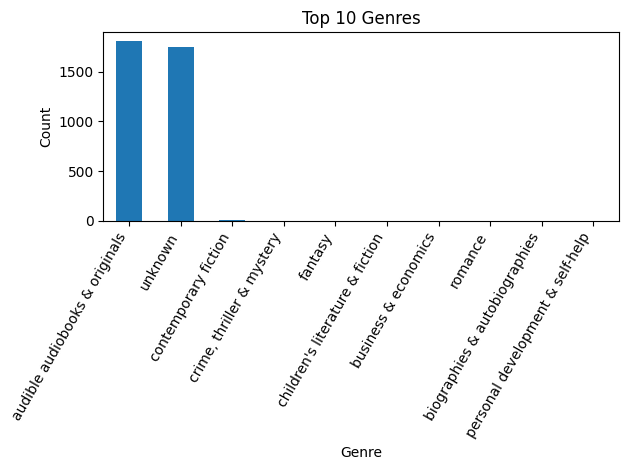

In [22]:
top_genres = df['clean_genre'].value_counts().head(10)

plt.figure()
top_genres.plot(kind='bar')
plt.title("Top 10 Genres")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.show()

In [23]:
df['content'] = (
    df['title'] + " " +
    df['author'] + " " +
    df['description']
)

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z ]', '', text)  # remove special chars
    return text

df['content'] = df['content'].apply(clean_text)

tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=5000
)

tfidf_matrix = tfidf.fit_transform(df['content'])

print(tfidf_matrix.shape)

(3624, 5000)


In [24]:
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

def recommend_books(book_title):
    book_title = book_title.lower()
    
    matches = df[df['title'].str.contains(book_title)]
    
    if matches.empty:
        suggestions = df[df['title'].str.contains(book_title[:3])]
        return suggestions['title'].head(5).values
    
    idx = matches.index[0]
    
    scores = list(enumerate(cosine_sim[idx]))
    scores = sorted(scores, key=lambda x: x[1], reverse=True)[1:6]
    
    book_indices = [i[0] for i in scores]
    
    return df[['title', 'author', 'rating']].iloc[book_indices]

recommend_books("rich")

,title,author,rating
847,rich dad's increase your financial iq: get sma...,robert t. kiyosaki,4.6
148,rich dad's guide to investing: what the rich i...,robert t. kiyosaki,4.5
3109,rich dad advisors: start your own corporation:...,garrett sutton,4.6
3436,banker to the poor: micro-lending and the batt...,muhammad yunus,4.6
1302,"rich dad advisors: tax-free wealth, 2nd editio...",tom wheelwright,4.7


In [25]:
kmeans = KMeans(n_clusters=10, random_state=42)

df['cluster'] = kmeans.fit_predict(tfidf_matrix)

df[['title', 'cluster']].head()

def recommend_by_cluster(book_title):
    book_title = book_title.lower()
    
    if book_title not in df['title'].values:
        return "Book not found"
    
    cluster_id = df[df['title'] == book_title]['cluster'].values[0]
    
    return df[df['cluster'] == cluster_id]['title'].head(5)

In [26]:
def recommend_content(title, k=5):
    title = title.lower()
    matches = df[df['title'].str.contains(title)]
    if matches.empty:
        return []
    
    idx = matches.index[0]
    scores = list(enumerate(cosine_sim[idx]))
    scores = sorted(scores, key=lambda x: x[1], reverse=True)[1:k+1]
    
    idxs = [i for i,_ in scores]
    return df[['title','author','rating']].iloc[idxs].reset_index(drop=True)

In [27]:
def recommend_cluster(title, k=5):
    title = title.lower()
    matches = df[df['title'].str.contains(title)]
    if matches.empty:
        return []
    
    idx = matches.index[0]
    cluster_id = df.loc[idx, 'cluster']
    
    recs = df[df['cluster'] == cluster_id]
    recs = recs[recs.index != idx]  # remove same book
    
    return recs[['title','author','rating']].head(k).reset_index(drop=True)

In [28]:
def recommend_hybrid(title, k=5):
    rec1 = recommend_content(title, k)
    rec2 = recommend_cluster(title, k)
    
    combined = pd.concat([rec1, rec2])
    combined = combined.drop_duplicates(subset='title')
    
    return combined.head(k).reset_index(drop=True)

In [29]:
def precision_at_k(recommended, relevant, k=5):
    recommended = list(recommended)[:k]
    relevant = set(relevant)
    
    hits = len([r for r in recommended if r in relevant])
    return hits / k

In [30]:
def recall_at_k(recommended, relevant, k=5):
    recommended = list(recommended)[:k]
    relevant = set(relevant)
    
    hits = len([r for r in recommended if r in relevant])
    return hits / len(relevant) if len(relevant) > 0 else 0

In [33]:
book = "rich"

# recommendations
content_rec = recommend_content(book)['title']
cluster_rec = recommend_cluster(book)['title']
hybrid_rec = recommend_hybrid(book)['title']

# define relevant set (same cluster)
idx = df[df['title'].str.contains(book)].index[0]
cluster_id = df.loc[idx, 'cluster']
relevant_books = df[df['cluster'] == cluster_id]['title']

content_prec = precision_at_k(content_rec, relevant_books)
cluster_prec = precision_at_k(cluster_rec, relevant_books)
hybrid_prec = precision_at_k(hybrid_rec, relevant_books)

content_recall = recall_at_k(content_rec, relevant_books)
cluster_recall = recall_at_k(cluster_rec, relevant_books)
hybrid_recall = recall_at_k(hybrid_rec, relevant_books)


In [34]:
models = ["Content-Based", "Cluster-Based", "Hybrid"]
precision = [content_prec, cluster_prec, hybrid_prec]
recall = [content_recall, cluster_recall, hybrid_recall]

f1 = [
    2 * p * r / (p + r) if (p + r) > 0 else 0
    for p, r in zip(precision, recall)
]

comparison_df = pd.DataFrame({
    "Model": models,
    "Precision@5": precision,
    "Recall@5": recall,
    "F1@5": f1
})

comparison_df

,Model,Precision@5,Recall@5,F1@5
0,Content-Based,0.4,0.011111,0.021622
1,Cluster-Based,1.0,0.027778,0.054054
2,Hybrid,0.4,0.011111,0.021622
